In [1]:
import numpy as np
import brisket
import sys
from astropy.io import fits

In [2]:
fit_instructions = {
    'redshift': (6.5,7.5),
    'galaxy1': {'model':'BC03','logMstar':(8,11),'metallicity':0.1,'sfh':'constant','age_min':0,'age_max':0.5}
}

def load_phot(ID):
    file = '/data/COSMOS-Web/catalogs/COSMOS-Web_supercatalog_pm_v0.7.fits'
    f = fits.getdata(file)
    f = f[f['id']==ID]
    fluxes = np.array([f['f_auto_f115w'][0],f['f_auto_f150w'][0],f['f_auto_f277w'][0],f['f_auto_f444w'][0]])
    errors = np.array([f['e_auto_f115w'][0],f['e_auto_f150w'][0],f['e_auto_f277w'][0],f['e_auto_f444w'][0]])
    return np.array([fluxes, errors]).T

# print(load_phot(756434))
gal = brisket.galaxy(756434, load_phot=load_phot, filt_list=['f115w','f150w','f277w','f444w'])

13:33:48 :: null :: INFO     :: Loading filters
13:33:48 :: null :: INFO     :: --------------------------------------------------------------------------------
13:33:48 :: null :: INFO     ::            Nickname -> Filter ID: Description
13:33:48 :: null :: INFO     ::       f115w -> jwst_nircam_f115w: JWST NIRCam F115W from SVO filter profile service
13:33:48 :: null :: INFO     ::       f150w -> jwst_nircam_f150w: JWST NIRCam F150W from SVO filter profile service
13:33:48 :: null :: INFO     ::       f277w -> jwst_nircam_f277w: JWST NIRCam F277W from SVO filter profile service
13:33:48 :: null :: INFO     ::       f444w -> jwst_nircam_f444w: JWST NIRCam F444W from SVO filter profile service
13:33:48 :: null :: INFO     :: --------------------------------------------------------------------------------


In [13]:
str(fit_instructions)

"{'redshift': (6.5, 7.5), 'galaxy1': {'model': 'BC03', 'logMstar': (8, 11), 'metallicity': 0.1, 'sfh': 'constant', 'age_min': 0, 'age_max': 0.5}}"

In [3]:
fit = brisket.fit(gal, fit_instructions, run='test_fit_0809', n_posterior=500)

In [4]:

fit.fit(verbose=True, n_live=100, use_MPI=False, sampler='ultranest', overwrite=True)

13:34:10 :: null :: INFO     :: Fitting object 756434
13:34:10 :: null :: INFO     :: Loading parameter dictionary
13:34:10 :: null :: INFO     :: Loading filters
13:34:10 :: null :: INFO     :: --------------------------------------------------------------------------------
13:34:10 :: null :: INFO     ::            Nickname -> Filter ID: Description
13:34:10 :: null :: INFO     ::       f115w -> jwst_nircam_f115w: JWST NIRCam F115W from SVO filter profile service
13:34:10 :: null :: INFO     ::       f150w -> jwst_nircam_f150w: JWST NIRCam F150W from SVO filter profile service
13:34:10 :: null :: INFO     ::       f277w -> jwst_nircam_f277w: JWST NIRCam F277W from SVO filter profile service
13:34:10 :: null :: INFO     ::       f444w -> jwst_nircam_f444w: JWST NIRCam F444W from SVO filter profile service
13:34:10 :: null :: INFO     :: --------------------------------------------------------------------------------
13:34:10 :: null :: INFO     :: Calculating optimal wavelength sampli

OSError: Fit results not found for 756434.

In [5]:
import numpy as np
x = np.linspace(400, 800, 100)
yerr = 1.0
y = np.random.normal(20 * np.exp(-0.5 * ((x-500)/4.2)**2), yerr)

Text(0, 0.5, 'y')

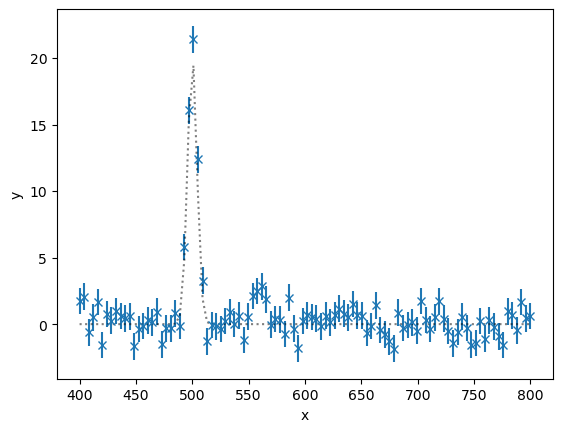

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.errorbar(x, y, yerr=yerr, ls=' ', marker='x')
plt.plot(x, 20 * np.exp(-0.5 * ((x-500)/4.2)**2), ls=':', alpha=0.5, color='k')
plt.xlabel('x')
plt.ylabel('y')

In [7]:
param_names = ['location', 'amplitude', 'width']

import scipy.stats

def my_prior_transform(cube):
    params = cube.copy()

    # transform location parameter: uniform prior
    lo = 400
    hi = 800
    params[0] = cube[0] * (hi - lo) + lo

    # transform amplitude parameter: log-uniform prior
    lo = 0.1
    hi = 100
    params[1] = 10**(cube[1] * (np.log10(hi) - np.log10(lo)) + np.log10(lo))

    # More complex prior, you can use the ppf functions
    # from scipy.stats, such as scipy.stats.norm(mean, std).ppf

    # transform for width:
    # a log-normal centered at 1 +- 1dex
    params[2] = 10**scipy.stats.norm.ppf(cube[2], 0, 1)

    return params

In [8]:
from numpy import log

def my_likelihood(params):
    location, amplitude, width = params
    # compute intensity at every x position according to the model
    y_model = amplitude * np.exp(-0.5 * ((x - location)/width)**2)
    # compare model and data with gaussian likelihood:
    like = -0.5 * (((y_model - y)/yerr)**2).sum()
    return like

In [9]:
import ultranest

sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform, log_dir='ultranest/test_run', resume='overwrite')

In [10]:
result = sampler.run()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-5e+01   [-50.0987..-50.0984]*| it/evals=5480/19382 eff=28.2162% N=276  6   
[ultranest] Likelihood function evaluations: 19395
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -64.96 +- 0.1331
[ultranest] Effective samples strategy satisfied (ESS = 1328.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.09 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.13 tail:0.01 total:0.13 required:<0.50
[ultranest] done iterating.


In [11]:
sampler.print_results()


logZ = -64.912 +- 0.180
  single instance: logZ = -64.912 +- 0.183
  bootstrapped   : logZ = -64.956 +- 0.180
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    location            : 499.48│ ▁▁▁▁▁▁▁▁▂▂▂▃▄▄▆▆▅▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁ ▁ │501.25    500.34 +- 0.21
    amplitude           : 18.17 │ ▁ ▁▁▁▁▁▁▂▁▃▃▃▅▆▆▆▇▇▇▇▇▆▅▄▄▃▂▁▁▁▁▁▁▁▁▁ │24.99     21.64 +- 0.88
    width               : 3.72  │ ▁▁▁▁▁▁▂▂▂▃▄▅▆▇▆▇▇▇▆▄▅▄▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁ │5.35      4.43 +- 0.20



In [21]:
sampler.results['weighted_samples']['logl']

array([-43903.9408621 , -36133.84755432, -33194.30376531, ...,
          -45.91406338,    -45.91390033,    -45.91383112])

In [51]:
sampler.results

{'niter': 4431,
 'logz': -71.52021706488995,
 'logzerr': 0.47009983160057156,
 'logz_bs': -71.49800996318967,
 'logz_single': -71.52021706488995,
 'logzerr_tail': 0.00991120235741505,
 'logzerr_bs': 0.46999534012446986,
 'ess': 968.6814541501142,
 'H': 13.1987847824156,
 'Herr': 0.19800133561909397,
 'posterior': {'mean': [499.85720294133375,
   19.705480025401183,
   4.1303837334524225],
  'stdev': [0.21458139464279666, 0.8719517807822573, 0.2243557628135452],
  'median': [499.85476404404426, 19.711686092856446, 4.1248916689983535],
  'errlo': [499.6439826992028, 18.806187778475515, 3.9097394234742846],
  'errup': [500.07556919371643, 20.582849245488372, 4.359985345637756],
  'information_gain_bits': [4.14647919764959,
   3.681513355348153,
   3.597925549367407]},
 'weighted_samples': {'upoints': array([[0.12304562, 0.93006429, 0.98024196],
         [0.11787406, 0.96657292, 0.95787211],
         [0.2399437 , 0.96040053, 0.95343547],
         ...,
         [0.24962642, 0.76535588, 0.73